Loading in necesary modules

In [2]:
!pip install ISLP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import os
import ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=8cbc2a3bc13a004f2522237d11a05d16fd64b0f7cc390705d25f11d667d93dfe
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


Loading in dataset and understanding its basic structure

In [3]:
df = ISLP.load_data('College')
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

  Private  Apps  Accept  Enroll  Top10perc  Top25perc  F.Undergrad  \
0     Yes  1660    1232     721         23         52         2885   
1     Yes  2186    1924     512         16         29         2683   
2     Yes  1428    1097     336         22         50         1036   
3     Yes   417     349     137         60         89          510   
4     Yes   193     146      55         16         44          249   

   P.Undergrad  Outstate  Room.Board  Books  Personal  PhD  Terminal  \
0          537      7440        3300    450      2200   70        78   
1         1227     12280        6450    750      1500   29        30   
2           99     11250        3750    400      1165   53        66   
3           63     12960        5450    450       875   92        97   
4          869      7560        4120    800      1500   76        72   

   S.F.Ratio  perc.alumni  Expend  Grad.Rate  
0       18.1           12    7041         60  
1       12.2           16   10527         56  
2    

Understanding distribution of variable of interest in dataset (public vs. private schools)

In [4]:
print(df['Private'].value_counts())

Private
Yes    565
No     212
Name: count, dtype: int64


Understanding acceptance rate trends for public and private schools

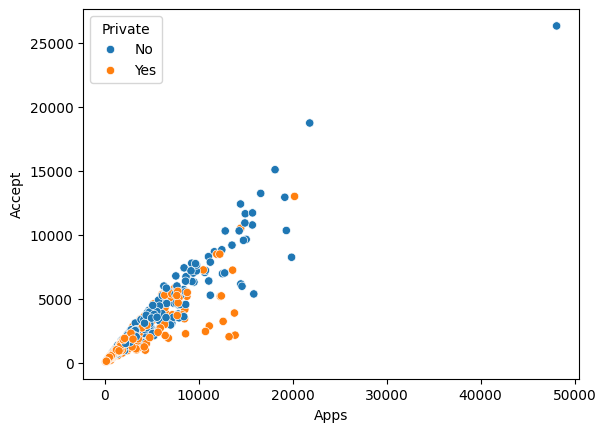

In [12]:
sns.scatterplot(x="Apps", y="Accept", hue="Private", data=df)
plt.show()

Defining a function to take one bootstrapped sample from the dataset (n=776 with resampling), dividing that sample into public vs. private schools, calculating the acceptance rate (a proportion) for each school, then returning the mean difference in proportions for the sample

In [4]:
def bootstrap_sample():
  priv_props = []
  pub_props = []
  for i in range(0,777):
    j = np.random.choice(range(0,777))
    if df.iloc[j]['Private'] =='Yes':
      priv_props.append((df.iloc[j]['Accept'])/(df.iloc[j]['Apps']))
    else:
      pub_props.append((df.iloc[j]['Accept'])/(df.iloc[j]['Apps']))

  priv_prop = sum(priv_props)/len(priv_props)
  pub_prop = sum(pub_props)/len(pub_props)
  return priv_prop - pub_prop

Creating a sampling distribution from many bootstrapped samples, plotting that sampling distrobution, and using the distribution to generate an estimate and 95% confidence interval for the true mean difference in acceptance rates between public and private colleges for all US colleges

In [8]:
samples = []
for i in range(0,1000):
  samples.append(bootstrap_sample())
samples = pd.DataFrame(samples)

                 0
count  1000.000000
mean      0.027502
std       0.011539
min      -0.010191
25%       0.019627
50%       0.027284
75%       0.034774
max       0.063742
0    0.050141
dtype: float64
0    0.004864
dtype: float64


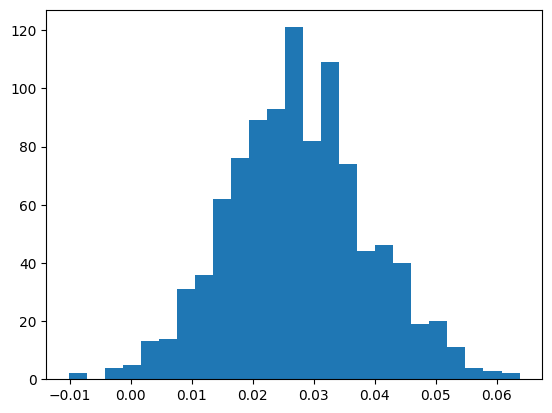

In [12]:
print(samples.describe())
print(samples.mean() + 1.962 * samples.std())
print(samples.mean() - 1.962 * samples.std())
plt.hist(samples, bins=25)
plt.show()